In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("messy_crm_sales_funnel_dataset.csv")



In [ ]:
df.head()


,Lead_ID,Lead_Source,Sales_Rep,Industry,Region,Created_Date,Qualified_Date,Demo_Date,Proposal_Date,Closed_Date,Deal_Status,Deal_Value
0,LEAD_107294,Google Ads,amit verma,Education,West,2025-10-21 10:41:08.238817,NaN,NaN,NaN,NaN,Lost,NaN
1,LEAD_109216,NaN,Rohit Kapoor,Healthcare,South,2026-01-31 10:41:08.238817,NaN,NaN,NaN,NaN,Lost,NaN
2,LEAD_114365,website,rahul sharma,NaN,South,2025-08-11 10:41:08.238817,2025-08-17 10:41:08.238817,2025-08-19 10:41:08.238817,NaN,NaN,Lost,NaN
3,LEAD_103891,Referral,Rohit Kapoor,Healthcare,NaN,2025-03-18 10:41:08.238817,2025-03-21 10:41:08.238817,2025-03-28 10:41:08.238817,2025-04-06 10:41:08.238817,2025-04-12 10:41:08.238817,Lost,NaN
4,LEAD_108912,LinkedIn,rahul sharma,Finance,East,2025-07-08 10:41:08.238817,2025-07-15 10:41:08.238817,NaN,NaN,NaN,Lost,NaN


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Lead_ID         18000 non-null  object 
 1   Lead_Source     15985 non-null  object 
 2   Sales_Rep       16026 non-null  object 
 3   Industry        14980 non-null  object 
 4   Region          14359 non-null  object 
 5   Created_Date    18000 non-null  object 
 6   Qualified_Date  13569 non-null  object 
 7   Demo_Date       8849 non-null   object 
 8   Proposal_Date   4923 non-null   object 
 9   Closed_Date     4923 non-null   object 
 10  Deal_Status     18000 non-null  object 
 11  Deal_Value      2186 non-null   float64
dtypes: float64(1), object(11)
memory usage: 1.6+ MB


In [ ]:
df.describe(include='all')

,Lead_ID,Lead_Source,Sales_Rep,Industry,Region,Created_Date,Qualified_Date,Demo_Date,Proposal_Date,Closed_Date,Deal_Status,Deal_Value
count,18000,15985,16026,14980,14359,18000,13569,8849,4923,4923,18000,2186.000000
unique,17750,8,8,5,4,365,373,382,387,391,2,NaN
top,LEAD_116206,website,Neha Singh,Retail,South,2025-08-18 10:41:08.238817,2025-10-28 10:41:08.238817,2025-08-16 10:41:08.238817,2026-02-21 10:41:08.238817,2025-05-23 10:41:08.238817,Lost,NaN
freq,4,2033,2071,3079,3623,69,58,39,24,28,15814,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101521.864593
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55482.488279
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5102.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54746.500000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101684.500000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,149552.250000


In [ ]:
df.isnull().sum()

,0
Lead_ID,0
Lead_Source,2015
Sales_Rep,1974
Industry,3020
Region,3641
Created_Date,0
Qualified_Date,4431
Demo_Date,9151
Proposal_Date,13077
Closed_Date,13077


In [ ]:
df.duplicated(subset=['Lead_ID']).sum()

np.int64(250)

In [ ]:
df['Created_Date'] = pd.to_datetime(df['Created_Date'], errors='coerce')

df = df.sort_values('Created_Date').drop_duplicates('Lead_ID', keep='last')

In [ ]:
df['Lead_Source'] = df['Lead_Source'].astype(str).str.strip().str.title()
df['Lead_Source'].replace("None", np.nan, inplace=True)
df['Lead_Source'].fillna("Unknown", inplace=True)

/tmp/ipython-input-1788395255.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Lead_Source'].replace("None", np.nan, inplace=True)
/tmp/ipython-input-1788395255.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [ ]:
df['Sales_Rep'] = df['Sales_Rep'].astype(str).str.strip().str.title()
df['Sales_Rep'].replace("None", np.nan, inplace=True)
df['Sales_Rep'].fillna("Unassigned", inplace=True)

/tmp/ipython-input-1723061559.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sales_Rep'].replace("None", np.nan, inplace=True)
/tmp/ipython-input-1723061559.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [ ]:
df['Industry'].fillna("Unknown", inplace=True)
df['Region'].fillna("Unknown", inplace=True)

/tmp/ipython-input-4066127417.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Industry'].fillna("Unknown", inplace=True)
/tmp/ipython-input-4066127417.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [ ]:
date_cols = ['Qualified_Date','Demo_Date','Proposal_Date','Closed_Date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [ ]:
df = df[
    (df['Qualified_Date'].isna()) | (df['Qualified_Date'] >= df['Created_Date'])
]

df = df[
    (df['Demo_Date'].isna()) | (df['Demo_Date'] >= df['Qualified_Date'])
]

df = df[
    (df['Proposal_Date'].isna()) | (df['Proposal_Date'] >= df['Demo_Date'])
]

df = df[
    (df['Closed_Date'].isna()) | (df['Closed_Date'] >= df['Proposal_Date'])
]

In [ ]:
df['Deal_Value'].fillna(0, inplace=True)

/tmp/ipython-input-197960626.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Deal_Value'].fillna(0, inplace=True)


In [ ]:
df['Qualified_Flag'] = np.where(df['Qualified_Date'].notna(),1,0)
df['Demo_Flag'] = np.where(df['Demo_Date'].notna(),1,0)
df['Proposal_Flag'] = np.where(df['Proposal_Date'].notna(),1,0)
df['Won_Flag'] = np.where(df['Deal_Status']=="Won",1,0)

In [ ]:
df['Days_to_Qualify'] = (df['Qualified_Date'] - df['Created_Date']).dt.days
df['Days_to_Demo'] = (df['Demo_Date'] - df['Qualified_Date']).dt.days
df['Days_to_Proposal'] = (df['Proposal_Date'] - df['Demo_Date']).dt.days
df['Days_to_Close'] = (df['Closed_Date'] - df['Proposal_Date']).dt.days

In [ ]:
df[['Days_to_Qualify','Days_to_Demo','Days_to_Proposal','Days_to_Close']] = \
df[['Days_to_Qualify','Days_to_Demo','Days_to_Proposal','Days_to_Close']].clip(lower=0)

In [ ]:
funnel_counts = {
    "Leads": len(df),
    "Qualified": df['Qualified_Flag'].sum(),
    "Demo": df['Demo_Flag'].sum(),
    "Proposal": df['Proposal_Flag'].sum(),
    "Won": df['Won_Flag'].sum()
}

pd.Series(funnel_counts)

,0
Leads,17750
Qualified,13379
Demo,8717
Proposal,4852
Won,2153


In [23]:
lead_to_qual = df['Qualified_Flag'].mean() * 100
qual_to_demo = df[df['Qualified_Flag']==1]['Demo_Flag'].mean() * 100
demo_to_prop = df[df['Demo_Flag']==1]['Proposal_Flag'].mean() * 100
prop_to_won = df[df['Proposal_Flag']==1]['Won_Flag'].mean() * 100

print(lead_to_qual, qual_to_demo, demo_to_prop, prop_to_won)

75.37464788732395 65.1543463637043 55.661351382356315 44.37345424567189


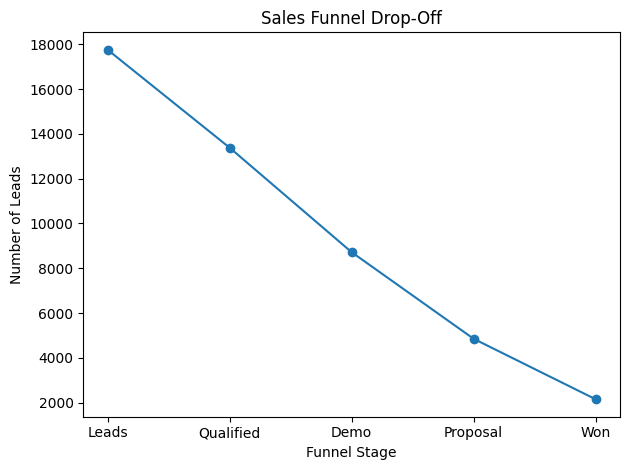

In [24]:
stage_values = list(funnel_counts.values())

plt.figure()
plt.plot(list(funnel_counts.keys()), stage_values, marker='o')
plt.title("Sales Funnel Drop-Off")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Leads")
plt.tight_layout()
plt.show()

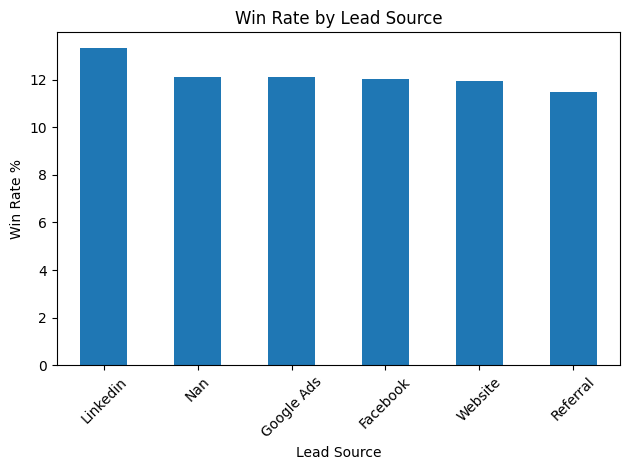

In [25]:
source_conversion = df.groupby('Lead_Source')['Won_Flag'].mean() * 100
source_conversion = source_conversion.sort_values(ascending=False)

plt.figure()
source_conversion.plot(kind='bar')
plt.title("Win Rate by Lead Source")
plt.xlabel("Lead Source")
plt.ylabel("Win Rate %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

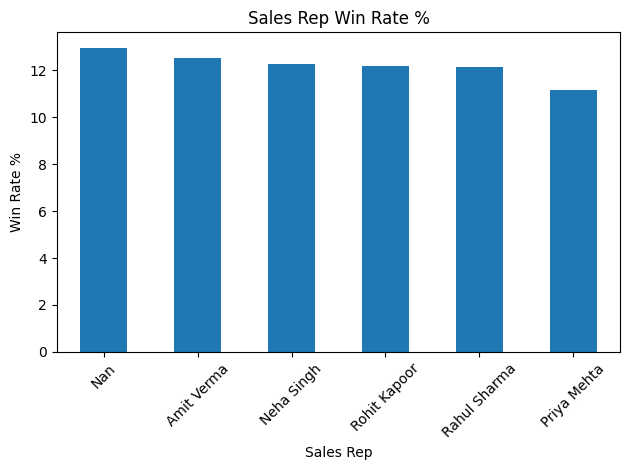

In [26]:
rep_performance = df.groupby('Sales_Rep').agg({
    'Won_Flag':'mean',
    'Deal_Value':'sum'
})

rep_performance['Won_Flag'] = rep_performance['Won_Flag'] * 100
rep_performance = rep_performance.sort_values('Won_Flag', ascending=False)

plt.figure()
rep_performance['Won_Flag'].plot(kind='bar')
plt.title("Sales Rep Win Rate %")
plt.xlabel("Sales Rep")
plt.ylabel("Win Rate %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
avg_close_time = df[df['Won_Flag']==1]['Days_to_Close'].mean()
avg_close_time

np.float64(7.436135624709707)